![head.png](figures/head.jpg)

# Financial Data Analytics in Python

**Prof. Dr. Fabian Woebbeking**</br>
Assistant Professor of Financial Economics

IWH - Leibniz Institute for Economic Research</br>
MLU - Martin Luther University Halle-Wittenberg

fabian.woebbeking@iwh-halle.de

In [1]:
# Packages used in this notebook
import numpy as np
import pandas as pd
from scipy import stats
from scipy import integrate
from scipy import optimize
import matplotlib.pyplot as plt

# Probabilities

* Uncertainty about outcomes lies at the heart of many financial applications.
* Quantifying the uncertainty in terms of probabilities enables us to do fun stuff, such as:
  * pricing derivatives or
  * measuring risk.
* Working wit probabilites in Python usually calls for NumPy and or SciPy.

See:
* https://docs.scipy.org/doc/scipy/tutorial/general.html

## Random numbers (`np.random`)

NumPy is a popular Python library used for scientific computing and data analysis. One of its most commonly used modules is `np.random`, which provides various functions for generating random numbers and arrays.

The `np.random` module uses a pseudo-random number generator algorithm to generate random numbers. This algorithm uses a starting value, called a seed, to generate a sequence of apparently random numbers. The sequence of numbers generated by the algorithm is not truly random, but it has many of the properties of a random sequence and is considered random enough for most applications.

The seed value can be set manually using the `np.random.seed()` function, which ensures that the sequence of numbers generated by the algorithm is the same each time the program is run. If the seed value is not set explicitly, Python uses the current system time as the default seed value.

See:
* https://numpy.org/doc/1.16/reference/routines.random.html

In [2]:
np.random.seed(seed=88888)

# Generate a random number between 0 and 1
print(np.random.rand())

# Generate an array of 5 random numbers between 0 and 1
print(np.random.rand(5))

# Generate a 2x3 array of random numbers between 0 and 1
print(np.random.rand(2, 3))

0.6768935286567954
[0.64422194 0.30171651 0.08426662 0.87314486 0.5639797 ]
[[0.39218695 0.45871883 0.07102008]
 [0.22815498 0.6499258  0.99057528]]


In [3]:
# Generate random numbers from a uniform distribution
uniform_nums = np.random.uniform(size=10000)

# Generate random numbers from a normal distribution
normal_nums = np.random.normal(loc=0, scale=1, size=10000)

# Generate random numbers from an exponential distribution
exponential_nums = np.random.exponential(scale=1, size=10000)

# Plot histograms of the three distributions
fig_disthist, axs = plt.subplots(1, 3, figsize=(16, 4))
axs[0].hist(uniform_nums, bins=20, color='blue', alpha=0.5)
axs[0].set_title('Uniform Distribution')
axs[1].hist(normal_nums, bins=20, color='green', alpha=0.5)
axs[1].set_title('Normal Distribution')
axs[2].hist(exponential_nums, bins=20, color='red', alpha=0.5)
axs[2].set_title('Exponential Distribution')
plt.close()

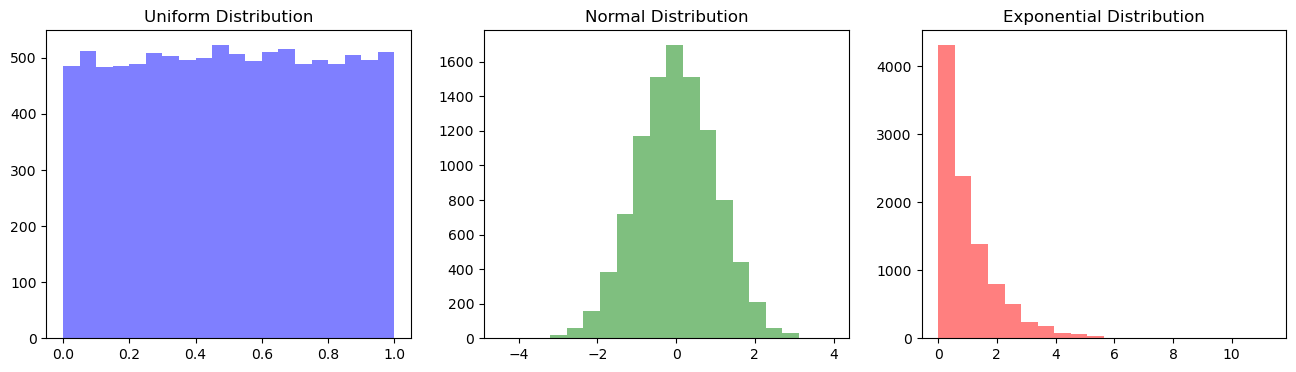

In [4]:
display(fig_disthist)

## Cholesky decomposition

[Cholesky decomposition](https://en.wikipedia.org/wiki/Cholesky_decomposition) is a matrix factorization technique that expresses a real, symmetric, and positive-definite matrix $A \in \mathbb{R}^{n \times n}$ as:

$$
A = LL^\top
$$

where $L$ is a lower-triangular matrix with strictly positive diagonal entries. In Python we use `np.linalg.cholesky()` to perform a Cholesky decomposition.

In this context, we focus on a key application: **simulating correlated random variables**, especially from a multivariate normal distribution.

### Simulating correlated normals

Let $X \sim \mathcal{N}(\mu, \Sigma)$, where:
- $\mu \in \mathbb{R}^n$ is the mean vector,
- $\Sigma \in \mathbb{R}^{n \times n}$ is the covariance matrix.

To simulate samples from this distribution:

1. Generate a vector $Z \sim \mathcal{N}(0, I)$ of independent standard normal variables.
2. Compute the Cholesky decomposition $\Sigma = LL^\top$.
3. Set:

$$
X = \mu + LZ
$$

Then $X \sim \mathcal{N}(\mu, \Sigma)$, with the desired mean and covariance structure.

> **Note**: Cholesky decomposition works best when applied to multivariate **normal** distributions, where linear transformations preserve both the marginal distributions and the correlation structure. For non-normal distributions, dependencies may not be preserved accurately — use copulas.


### Covariance vs. correlation matrix

You can also apply Cholesky decomposition to a **correlation matrix** $R$, which standardizes the output variables:

- Using $\Sigma$: Preserves both **variances** and **correlations** → results in properly scaled output.
- Using $R$: Preserves **correlations only** → output has unit variance.

> **Note**: Cholesky decomposition requires the input matrix to be symmetric and positive-definite. For empirical correlation matrices, regularization may be necessary to ensure this.


In [5]:
# Define the correlation matrix
corr_matrix = np.array([[1.0, 0.9], [0.9, 1.0]])

# Perform Cholesky decomposition
cholesky_decomp = np.linalg.cholesky(corr_matrix)

# Generate uncorrelated random numbers
uncorrelated_nums = np.random.normal(size=(2, 10000))

# Transform the uncorrelated random numbers into correlated random numbers
corr_nums = np.dot(cholesky_decomp, uncorrelated_nums)

# Plot the correlated random numbers
fig_corrrandom, ax = plt.subplots()
plt.scatter(corr_nums[0], corr_nums[1], s=2)
plt.close()

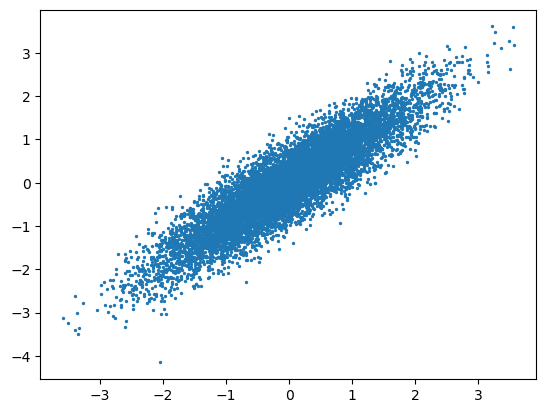

In [6]:
display(fig_corrrandom)

## Probability distributions (`scipy.stats`)

Scipy is a powerful Python library for scientific computing and data analysis that provides a wide range of tools and functions for mathematical optimization, integration, signal processing, and statistics. Within the Scipy library, the scipy.stats module provides a comprehensive set of statistical functions and tools for working with probability distributions and performing statistical tests.

Consider random variable $X \sim \mathcal{N}(\mu,\sigma^2)$ as an example for a continuous univariate distribution, i.e. the [normal distribution](https://en.wikipedia.org/wiki/Normal_distribution), with:

Probability density function (PDF):
$$\phi(x) = \frac{d\Phi(x)}{dx} = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2} \left( \frac{x-\mu}{\sigma} \right)^2 }$$


Cumulative distribution function (CDF):
$$\Phi(x) = P(X \le x) = \int_{-\infty}^x \phi(u)\; du$$

Quantile function, i.e. inverse of the CDF:
$$\Phi^{-1}(p) = \inf \{x \in \mathbb{R}: p \le \Phi(x)\},\;\; p \in (0,1)$$

In [7]:
x = np.linspace(-3, 3, 100)
p = np.linspace(0, 1)
# Plot histograms of the three distributions
fig_disthist, axs = plt.subplots(1, 3, figsize=(16, 4))
axs[0].plot(x, stats.norm.pdf(x, 0, 1))
axs[0].plot(x, stats.norm.pdf(x, 1, 1))
axs[0].plot(x, stats.norm.pdf(x, 0, 1.5))
axs[0].axvline(x=0, color='grey', linewidth=.75)
axs[0].set_title('Probability Density Function (PDF)')
axs[1].plot(x, stats.norm.cdf(x, 0, 1))
axs[1].plot(x, stats.norm.cdf(x, 1, 1))
axs[1].plot(x, stats.norm.cdf(x, 0, 1.5))
axs[1].axvline(x=0, color='grey', linewidth=.75)
axs[1].set_title('Cumulative Distribution Function (CDF)')
axs[2].plot(p, stats.norm.ppf(p, 0, 1))
axs[2].plot(p, stats.norm.ppf(p, 1, 1))
axs[2].plot(p, stats.norm.ppf(p, 0, 1.5))
axs[2].axvline(x=0.5, color='grey', linewidth=.75)
axs[2].set_title('Quantile function (inverse CDF)')
plt.close()

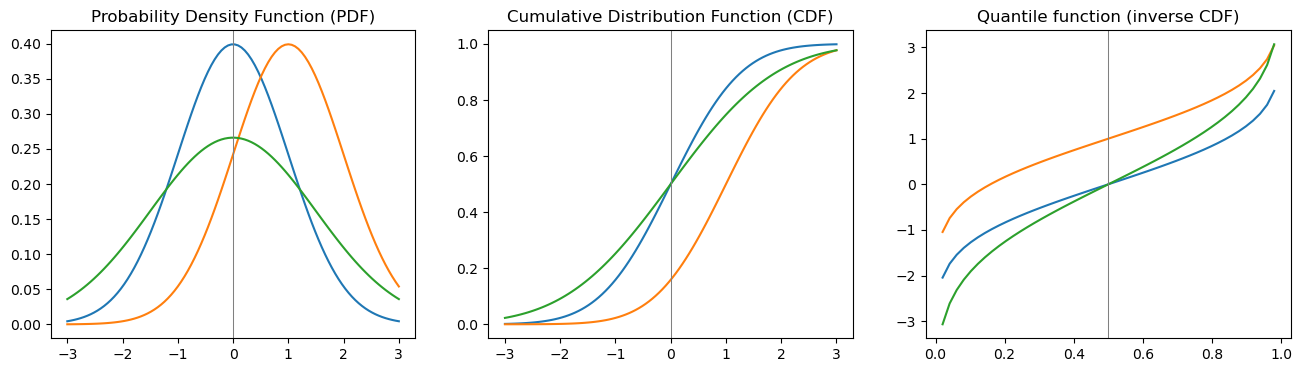

In [8]:
display(fig_disthist)

## Numerical integration (`scipy.integrate`)

Numerical integration, also known as numerical quadrature, is a method for approximating the integral of a function using numerical techniques. The Scipy library provides a number of functions for numerical integration in `scipy.integrate`.

See:
* https://docs.scipy.org/doc/scipy/reference/integrate.html

In [9]:
# read on the use of lambda here: https://docs.python.org/3/reference/expressions.html#lambda
result, error = integrate.quad(lambda x: stats.norm.pdf(x, 0, 1), -np.inf, +np.inf)
print(f"{result:.4f}")

result, error = integrate.quad(lambda x: stats.norm.pdf(x, 0, 1), -np.inf, 1.96)
print(f"{result:.4f}")

print(f"{stats.norm.cdf(1.96, 0, 1):.4f}")

1.0000
0.9750
0.9750


As another example, we estimate the integral 

$$
\int_0^1 (2\sin(15 x) + 15 x)\, d x.
$$

The solution, calculated analytically, is $\displaystyle\frac{1}{30} \left(229-4 \cos(15)\right)=7.7346$. We will pick up this example again in the Monte Carlo section.

In [10]:
def f(x):
    return 2 * np.sin(15*x) + 15*x

# Compute the definite integral of f(x) from 0 to 1
result, error = integrate.quad(f, 0, 1)
print(f"The integral of f(x) from 0 to 1 is: {result:,.4f}")

# Plot the function f(x)
x = np.linspace(0, 1, 100)
y = f(x)
fig_integral = plt.figure(figsize=(8, 4))
plt.plot(x, y)
plt.fill_between(x, y, alpha=0.2)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('$f(x) = 2 \sin(15 x) + 15 x$')
plt.close()

The integral of f(x) from 0 to 1 is: 7.7346


<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\s'
/var/folders/58/kl_08cg55q31sf20m8r4wyrh0000gn/T/ipykernel_74878/1765537904.py:16: SyntaxWarning: invalid escape sequence '\s'
  plt.title('$f(x) = 2 \sin(15 x) + 15 x$')


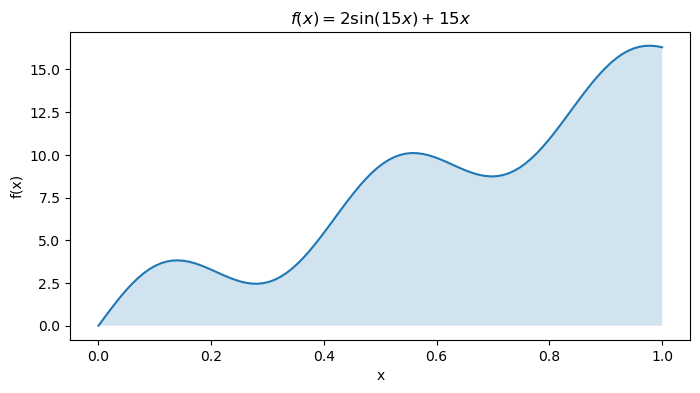

In [11]:
display(fig_integral)

# Numerical optimization (`scipy.optimize`)

One of SciPy's its many powerful sub-modules is `scipy.optimize`, which provides a wide array of optimization algorithms for different types of problems. In this tutorial, we will introduce you to three main categories of optimization problems and how to solve them using the `scipy.optimize` module.

See: 
* https://docs.scipy.org/doc/scipy/reference/optimize.html

Consider as an example the function

$$
x^2 + 10 \sin(x).
$$

In [12]:
def func(x):
    return x**2 + 10 * np.sin(x)

x = np.linspace(-10, 10, 1000)  # Generate 1000 equally spaced points between -10 and 10
y = func(x)

fig_func = plt.figure(figsize=(8, 4))
plt.plot(x, y)
plt.axvline(x=-1.30644002, color='red', linestyle='--', label=f'Global')
plt.axvline(x=3.8374671, color='green', linestyle='--', label=f'Local')
plt.axvline(x=3.5, color='blue', linestyle='--', label=f'Constr.')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('f(x) = x^2 + 10 * sin(x)')
plt.grid()
plt.legend()
plt.close()

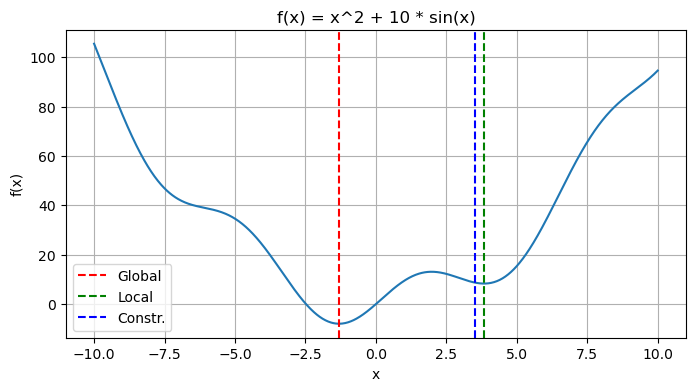

In [13]:
display(fig_func)

## Global Optimization

Global optimization algorithms seek the global minimum of a function over a given interval or domain. One popular method for global optimization is the Basin-hopping algorithm, which combines local minimization with random perturbations to escape local minima. Here is an example using `scipy.optimize.basinhopping`:

In [14]:
x0 = 2.5
result = optimize.basinhopping(func, x0, niter=1000)
print(f"Global minimum: x = {result.x}, f(x) = {result.fun}")

Global minimum: x = [-1.30644001], f(x) = -7.9458233756152845


## Local Optimization

Local optimization algorithms focus on finding a local minimum in the vicinity of the starting point. One such method is the Broyden–Fletcher–Goldfarb–Shanno (BFGS) algorithm, which is a quasi-Newton method. You can use `scipy.optimize.minimize` with the `method='BFGS'` argument:

In [15]:
x0 = 2.5
result = optimize.minimize(func, x0, method='BFGS')
print(f"Local minimum: x = {result.x}, f(x) = {result.fun}")

Local minimum: x = [3.83746712], f(x) = 8.31558557947746


## Constrained Optimization

Constrained optimization problems involve finding the minimum of a function subject to constraints. The Sequential Least Squares Programming (SLSQP) algorithm is a popular method for solving such problems.In this case we want to find the minimum of $f(x)$ subject to the constraint

$$
0.5 \le x \le 3.5
$$

Here's an example using `scipy.optimize.minimize` with `method='SLSQP'`:

In [16]:
x0 = 2.5
bounds = [(0.5, 3.5)]
result = optimize.minimize(func, x0, method='SLSQP', bounds=bounds)
print(f"Constrained minimum: x = {result.x}, f(x) = {result.fun}")

Constrained minimum: x = [3.5], f(x) = 8.742167723103815


We can hand more complex constraints to `scipy.optimize.minimize` through the `constraints` argument, you'll need to define the constraints as functions and specify their types (‘eq’ for equality or ‘ineq’ for inequality constraints). In our case, we want to enforce the constraint $0.5 \le x \le 3.5$, which can be rewritten as $x - 0.5 \ge 0$ and $3.5 - x \ge 0$.

In [17]:
def constraint1(x):
    return x - 0.5

def constraint2(x):
    return 3.5 - x

# 
cons = (
    {'type': 'ineq', 'fun': constraint1},
    {'type': 'ineq', 'fun': constraint2}
    )

x0 = 2.5
result = optimize.minimize(func, x0, method='SLSQP', constraints=cons)
print(f"Constrained minimum: x = {result.x}, f(x) = {result.fun}")

Constrained minimum: x = [3.5], f(x) = 8.742167723103815


# Monte Carlo simulation

[Monte Carlo simulation](https://de.wikipedia.org/wiki/Monte-Carlo-Simulation) is a computational technique that uses statistical sampling to estimate the behavior of complex systems or processes. It was first developed by scientists working on the Manhattan Project in the 1940s to solve problems related to nuclear weapons research. More specifically, Monte Carlo simulation refers to the simulation of (independent) samples of a random variable $Z$ using computer-generated random numbers. Once sufficiently many random numbers have been drawn, these can be used to produce an **estimate** of some quantity that depends on the distribution of $Z$. The quality of an estimate can be quantified by a **confidence interval** around the estimate. (For a comprehensive source, see: Paul Glasserman.  *Monte Carlo Methods in Financial Engineering*. Springer, 2004.)

Consider the problem of estimating the integral of a function $f$ **over the unit interval**:

$$
{\mathcal I} = \int_0^1 f(x)\, d x. 
$$


We may write
$$
{\mathcal I}=\mathbb E[f(U)], 
$$
with $U$ uniformly distributed between $0$ and $1$. Drawing points $u_1,u_2,\ldots, u_n$ independently and uniformly from $[0,1]$, the **Monte Carlo estimate** is given by

$$
\hat{\mathcal I}_n = \frac{1}{n} \sum_{i=1}^n f(u_i). 
$$

If $f$ is integrable over $[0,1]$ then, by the **strong law of large numbers**,
$$
\hat {\mathcal I}_n\rightarrow {\mathcal I} \text{ with probability } 1, \text{ as } n\rightarrow\infty. 
$$

If $f$ is square integrable, and setting,
$$
\sigma_f^2 = \int_0^1 (f(x)-{\mathcal I})^2\, d x,
$$
then, by the **central limit theorem**, the error $\hat{\mathcal I}_n-{\mathcal I}$ is approximately normally distributed with mean $0$ and standard deviation $\sigma_f/\sqrt{n}$.

$\sigma_f$ is typically unknown, but can be estimated by the  sample standard deviation 
$$
s_f = \sqrt{\frac{1}{n-1} \sum_{i=1}^n (f(u_i)-\hat{\mathcal I}_n)^2}. 
$$

Thus, an (asymptotically) valid $1-\delta$ confidence interval for ${\mathcal I}$ is given by
$$
\left[\hat\alpha_n- z_{1-\delta/2} \frac{s_f}{\sqrt{n}}\,\,,\,\, \hat\alpha_n+ z_{1-\delta/2} \frac{s_f}{\sqrt{n}}\right],
$$
where $z_{1-\delta/2} = \Phi^{-1}(1-\delta/2)$ denotes the $1-\delta/2$ quantile of the standard normal distribution. For example, for $1-\delta=0.95$: $z_{1-\delta/2} =  z_{0.975} \approx 1.96$. 

Thus, from the function value $f(u_1), \ldots, f(u_n)$ we obtain
* an estimate of the integral ${\mathcal I}$,
* and a measure of the error of the estimate.

The form of the standard error $\sigma_f/\sqrt{n}$ implies:
* to cut the error in half requires increasing the sample size by four;
* adding one decimal point of precision requires $100$ times as many points. 

In [18]:
# Generate random numbers, ...
n = 100000
np.random.seed(123)
z = np.random.uniform(0, 1, n)
# .. and calculate values for f(x)
y = f(z)

# Show estimate for different numbers of simulations (n)
y_m = []
y_cfl = []
y_cfu = []
for i in range(1000, n+1, 1000):
    y_m.append(np.mean(y[:i]))
    y_cfl.append(np.mean(y[:i] - 1.96 * np.std(y[:i])/np.sqrt(i)))    
    y_cfu.append(np.mean(y[:i] + 1.96 * np.std(y[:i])/np.sqrt(i)))

fig_mcintegral = plt.figure(figsize=(8,4))
plt.plot(range(1000,n+1,1000), y_m, color='blue', label='Mean')
plt.plot(range(1000,n+1,1000), y_cfu, color='green', label='Upper confidence level')
plt.plot(range(1000,n+1,1000), y_cfl, color='green', label='Lower confidence level')
plt.axhline(y=7.7346, color='red', linewidth=.75)
plt.xlabel('Number of simulations (n)')
plt.ylabel('Estimate')
plt.legend(loc='upper right')
plt.close()

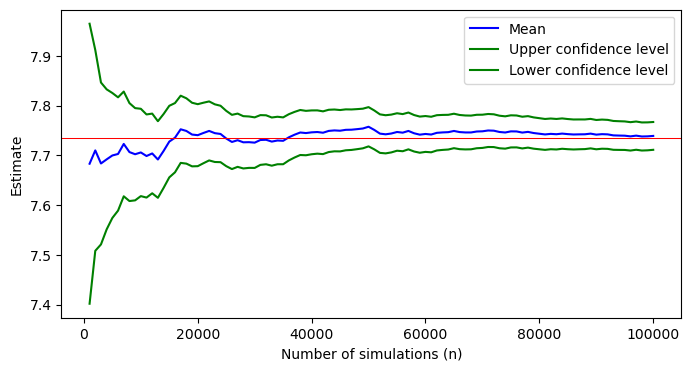

In [19]:
display(fig_mcintegral)

## Stochastic processes

### Markov property

In probability theory and statistics, the term Markov property refers to the memoryless property of a stochastic process, i.e. only the present price is relevant for predicting the future. Markov property is consistent with the **weak form of market efficiency!**

### Generalized Wiener process
A stochastic process $X$, with drift $\mu$ and dispersion $\sigma$, follows a generalized Wiener process if it satisfies the following stochastic differential equation (SDE)

$$
dX_t = \mu \times dt + \sigma \times dW_t
$$

Note that by definition, the **increments** of a Wiener process are normally distributed. Specifically, for any $t > 0$,

$$
W_t - W_0 \sim \mathcal{N}(0, t)
$$

—that is, they are normally distributed with mean zero and variance $t$.

For an arbitrary initial value $X_0$:

$$
X_t = X_0 + \mu \times t + \sigma \times z \times \sqrt{t}
$$

where $z \sim \mathcal{N}(0, 1)$.


### Geometric Brownian Motion

A stochastic process $S$ follows a **Geometric Brownian Motion (GBM)** if it satisfies the following stochastic differential equation (SDE):

$$
dS_t = \mu S_t \, dt + \sigma S_t \, dW_t
$$

where $W_t$ is a **Wiener process**, i.e. a continuous-time stochastic process with normally distributed increments. Specifically, for any $t > 0$, the increment $W_t - W_0 \sim \mathcal{N}(0, t)$.


#### Itô's Lemma

To derive the distribution and solution of the GBM, we apply **Itô’s Lemma**, which is the stochastic calculus analog of the chain rule. It allows us to compute the differential of a function of a stochastic process. See Itô, K. (1951). On stochastic differential equations (No. 4). American Mathematical Soc..

Let $S_t$ follow the SDE above, and define a new process $X_t = \ln S_t$. Then, by Itô’s Lemma:

$$
dX_t = \left( \frac{1}{S_t} \mu S_t - \frac{1}{2} \frac{1}{S_t^2} \sigma^2 S_t^2 \right) dt + \frac{1}{S_t} \sigma S_t \, dW_t = \left( \mu - \frac{\sigma^2}{2} \right) dt + \sigma \, dW_t
$$

Integrating both sides from $0$ to $t$ gives:

$$
X_t = X_0 + \left( \mu - \frac{\sigma^2}{2} \right)t + \sigma W_t
$$



Since $X_0 = \ln S_0$, we obtain the analytical solution:

$$
\ln S_t = \ln S_0 + \left( \mu - \frac{\sigma^2}{2} \right)t + \sigma W_t
$$

Exponentiating both sides yields the solution to the GBM:

$$
S_t = S_0 \exp\left( \left(\mu - \frac{\sigma^2}{2}\right) t + \sigma W_t \right)
$$




#### Distribution of Returns

Therefore, we also have:

$$
\ln \frac{S_t}{S_0} = \left(\mu - \frac{\sigma^2}{2}\right) t + \sigma W_t
$$

Note that $W_t = z \sqrt{t}$ for $z \sim \mathcal{N}(0,1)$, which implies that $\ln \frac{S_t}{S_0}$ (log-return) is **normally distributed**, and $S_t$ is **log-normally distributed**.

In [20]:
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

#%% Create stock process:
# Random numbers N(0,1)
np.random.seed(888)
Z = np.random.normal(0, 1, 250)
def plot_gbm(mu, sigma):
    # returns for our geometric brownian motion
    R = Z * sigma * np.sqrt(1/250) + (mu-0.5*sigma**2) * 1/250
    # stock process (insert 100 for t=0)
    S = np.insert(100*np.exp(np.cumsum(R)), 0, 100)
    # Plotting
    plt.figure('GBM process', figsize=(8,4))
    plt.title(f"GBM ($\mu$ = {mu:,.2f}, $\sigma$ = {sigma:,.2f})")
    plt.axhline(y = 100, color ="black", linestyle ="--", linewidth=1)
    plt.plot(S)
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.ylim(30, 170)
    plt.show()

<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\s'
/var/folders/58/kl_08cg55q31sf20m8r4wyrh0000gn/T/ipykernel_74878/2876744793.py:18: SyntaxWarning: invalid escape sequence '\m'
  plt.title(f"GBM ($\mu$ = {mu:,.2f}, $\sigma$ = {sigma:,.2f})")
/var/folders/58/kl_08cg55q31sf20m8r4wyrh0000gn/T/ipykernel_74878/2876744793.py:18: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"GBM ($\mu$ = {mu:,.2f}, $\sigma$ = {sigma:,.2f})")


In [21]:
interact(plot_gbm, 
         mu = widgets.FloatSlider(value=0.1, min=-0.5, max=0.5, step=0.05),
         sigma = widgets.FloatSlider(value=0.25, min=0, max=0.9, step=0.05),
        )

interactive(children=(FloatSlider(value=0.1, description='mu', max=0.5, min=-0.5, step=0.05), FloatSlider(valu…

<function __main__.plot_gbm(mu, sigma)>

# Asset valuation

One of the key applications of Monte Carlo simulation in financial economics is to assess the value of contingent claims, such as options, derivatives, and hybrid instruments. To put it simply, in a risk-neutral-world, the value of a contingent claim is determined by calculating the expected payoff and then discounting it under the risk-neutral (martingale) measure. This probability measure ensures that all risk factors, such as stocks and indices, follow the risk-free short rate, which makes the discounted processes martingales. As per the Fundamental Theorem of Asset Pricing, the availability of this probability measure is equivalent to the absence of arbitrage.

## Option valuation

As a valuation example, let us consider a financial option. In finance, an option is a type of derivative contract that gives the buyer the right, but not the obligation, to buy or sell an underlying asset at a specific price (called the "strike price") on or before a specified expiration date. Options can be traded on a variety of underlying assets, such as stocks, bonds, commodities, currencies, and market indexes.

The cash flow of an [option](https://en.wikipedia.org/wiki/Option_(finance)) with strike $K$ at maturity $T$ is given by

$$
\max(S_T - K, 0) = (S_T - K)^+
$$

for the so-called **Call option** (right to buy) and 

$$
\max(K - S_T, 0) = (K - S_T)^+
$$

for the **Put option** (right to sell), where $S_T$ is the price of the underlying at $T$. 

The value and, hence, the fair market price of the option under the [risk-neutral measure](https://en.wikipedia.org/wiki/Risk-neutral_measure) $\mathbb{Q}$ is simply its discounted expected value, hence, for the Call option

$$
\mathbb{E}^Q[(S_T - K)^+] e^{-rT}
$$

and for the Put

$$
\mathbb{E}^Q[(K - S_T)^+] e^{-rT}.
$$



A closed form solution for an option that can only be exercised at maturity (European option) is the famous [Black–Scholes model](https://en.wikipedia.org/wiki/Black%E2%80%93Scholes_model), where the present value for a Call option is

$$S_0 \Phi(d_+)− K e^{-rT} \Phi(d_-)$$

and for the Put option

$$K e^{-rT} \Phi(-d_-) − S_0 \Phi(-d_+)$$

with

$$d_\pm = \frac{\ln\frac{S_0}{K} + rT \pm \sigma^2 \frac{T}{2}}{\sigma \sqrt{T}}$$

In this class, we are not interested in the closed form solution, however, we will use it as a base line value to test other methods, such as Monte Carlo simulation.

In [22]:
import numpy as np
import matplotlib.pyplot as plt

K = 100  # Strike price
S_T = np.arange(1, 200, 1)  # Stock price range
# Define some arbitrary parameters for the valuation
T = 1  # Maturity
r = 0.05  # Risk-free rate
sigma = 0.25  # Volatility of the underlying

# The famous Black-Scholes model (we use this as a benchmark)
def black_scholes(cpflag,S,K,T,r,sigma):
    # cpflag in {1 for call, -1 for put}
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = (np.log(S / K) + (r - 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    price = cpflag * (S * stats.norm.cdf(cpflag*d1, 0.0, 1.0) - K * np.exp(-r * T) * 
            stats.norm.cdf(cpflag*d2, 0.0, 1.0))
    return price

print(f"The Black Scholes Call price: black_scholes(1, 100,K,T,r,sigma) = {black_scholes(1, 100,K,T,r,sigma):.2f}")

The Black Scholes Call price: black_scholes(1, 100,K,T,r,sigma) = 12.34


In [23]:
# Plot the call and put payouts and option prices on two subplots
fig_optionpayout, axs = plt.subplots(1, 2, figsize=(16, 9/2))
# Call option
axs[0].plot(S_T, np.maximum(S_T - K, 0), label='$(S_T - K)^+$')
axs[0].plot(S_T, black_scholes(1, S_T, K, T, r, sigma), label='$\mathbb{E}^Q[(S_T - K)^+] e^{-rT}$')
axs[0].set_xlabel('Price of the underlying')
axs[0].set_ylabel('Payout / Option value')
axs[0].title.set_text("Call option")
axs[0].legend()
# Put option
axs[1].plot(S_T, np.maximum(K - S_T, 0), label='$(K - S_T)^+$')
axs[1].plot(S_T, black_scholes(-1, S_T, K, T, r, sigma), label='$\mathbb{E}^Q[(K - S_T)^+] e^{-rT}$')
axs[1].set_xlabel('Price of the underlying')
axs[1].set_ylabel('Payout / Option value')
axs[1].title.set_text("Put option")
axs[1].legend()
plt.close()

<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
/var/folders/58/kl_08cg55q31sf20m8r4wyrh0000gn/T/ipykernel_74878/466796689.py:5: SyntaxWarning: invalid escape sequence '\m'
  axs[0].plot(S_T, black_scholes(1, S_T, K, T, r, sigma), label='$\mathbb{E}^Q[(S_T - K)^+] e^{-rT}$')
/var/folders/58/kl_08cg55q31sf20m8r4wyrh0000gn/T/ipykernel_74878/466796689.py:12: SyntaxWarning: invalid escape sequence '\m'
  axs[1].plot(S_T, black_scholes(-1, S_T, K, T, r, sigma), label='$\mathbb{E}^Q[(K - S_T)^+] e^{-rT}$')


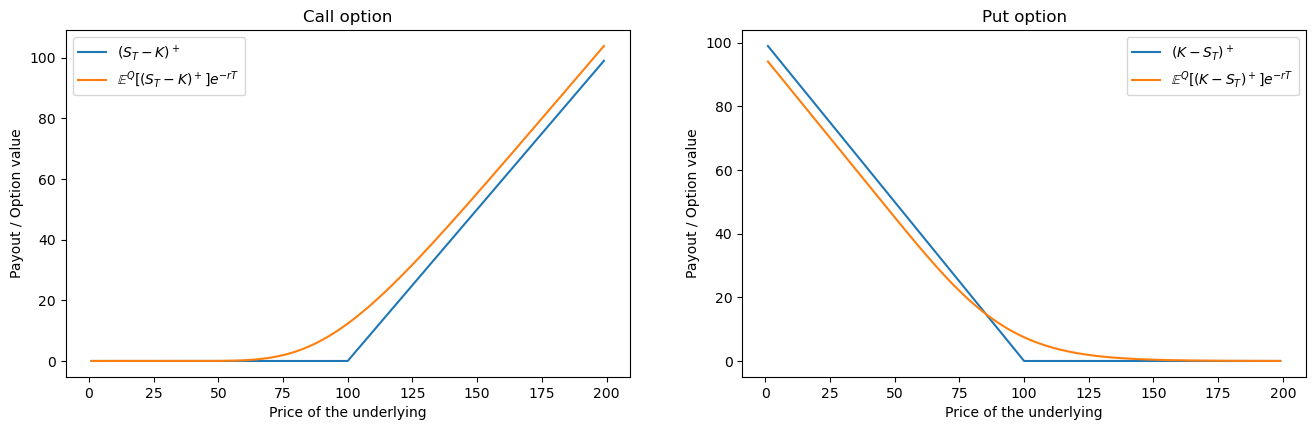

In [24]:
display(fig_optionpayout)

# Risk measures

There exists a plethora of risk measures, geared towards different tasks and applications. We will focus on a few very common measures, such as Value at Risk (VaR).

## Value at Risk (VaR)

[Value at Risk (VaR)](https://en.wikipedia.org/wiki/Value_at-risk) is a widely used **market risk measure** in finance that estimates the potential loss in the value of a portfolio due to market risk over a specified time horizon, at a given confidence level. In other words, VaR measures the maximum loss that a portfolio can incur within a specified time period, with a certain probability. For example, a 1‑day VaR of EUR 1 million at a 95 % confidence level indicates that there is a 5 % chance that the portfolio will lose more than EUR 1 million in a single day.

Formally, the VaR of the position change $-\Delta V$ is

$$
\mathrm{VaR}_\alpha(-\Delta V)
= \inf \bigl\{ I \in \mathbb{R} : \mathbb{P}(-\Delta V > I) \le 1 - \alpha \bigr\}
= Q_\alpha(-\Delta V),
$$

where $Q_\alpha(-\Delta V)$ denotes the $\alpha$‑quantile of the distribution of $-\Delta V$.

There are several methods to compute VaR, including:

In [25]:
# Generate random daily returns for a two stock portfolio
np.random.seed(42)
num_days = 252*10  # 10 years of daily returns
returns_A = np.random.normal(loc=0.001, scale=0.02, size=num_days)
returns_B = np.random.normal(loc=0.0005, scale=0.015, size=num_days)
# Create a DataFrame with the returns
returns = pd.DataFrame({'A': returns_A, 'B': returns_B})
# Calculate portfolio weights (50% each)
weights = np.array([0.5, 0.5])
# Calculate portfolio returns
portfolio_returns = returns.dot(weights)

In [26]:
fig_portfolio, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(portfolio_returns.index, portfolio_returns, color='grey', label='Portfolio Returns')
ax1.set_xlabel('Time')
ax1.set_ylabel('Portfolio Returns', color='grey')
ax1.tick_params(axis='y', labelcolor='grey')
ax2 = ax1.twinx()
ax2.plot(portfolio_returns.index, portfolio_returns.cumsum(), color='red', label='Cumulative Returns')
ax2.set_ylabel('Cumulative Returns', color='red')
ax2.tick_params(axis='y', labelcolor='red')
plt.suptitle('Portfolio Returns')
plt.tight_layout()
plt.close()

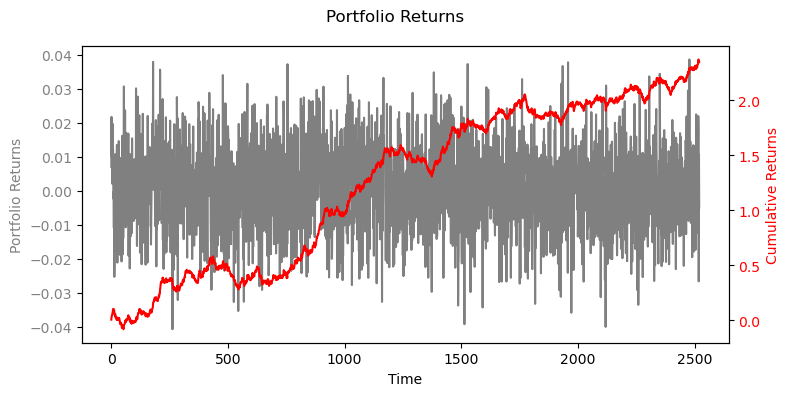

In [27]:
display(fig_portfolio)

### Parametric VaR (Variance–Covariance Method)

Parametric VaR, also known as the variance–covariance method, assumes that portfolio returns (or changes in value) follow a multivariate normal distribution. Denote the change in portfolio value over the horizon by $\Delta V$, with

- mean: $\mu_{\Delta V} = \mathbb{E}[\Delta V]$  
- standard deviation: $\sigma_{\Delta V} = \sqrt{\mathrm{Var}(\Delta V)}$  

Let $z_{1-\alpha} = \Phi^{-1}(1-\alpha)$ be the $(1-\alpha)$‑quantile of the standard normal distribution (e.g. $z_{0.05}\approx -1.645$ for $\alpha=0.95$). Then the $\alpha$‑VaR is given by

$$
\mathrm{VaR}_\alpha
= -\bigl(\mu_{\Delta V} + \sigma_{\Delta V}\,z_{1-\alpha}\bigr)
= -\mu_{\Delta V} \;-\; z_{1-\alpha}\,\sigma_{\Delta V}.
$$

Equivalently, since $z_{1-\alpha}<0$, one often writes

$$
\mathrm{VaR}_\alpha
= -\mu_{\Delta V} + \Phi^{-1}(\alpha)\,\sigma_{\Delta V},
$$

where $\Phi^{-1}(\alpha)=-\,z_{1-\alpha}$ is the $\alpha$‑quantile of the standard normal.



**Procedure:**
1. Estimate $\mu_{\Delta V}$ and $\sigma_{\Delta V}$ from historical returns or a risk‑factor model.  
2. Compute $z_{1-\alpha}$ from the standard normal distribution.  
3. Plug into the formula above to get $\mathrm{VaR}_\alpha$.

**Pros:**
- Highly efficient to compute, even for large portfolios.  
- Easy to update as new mean/covariance data arrive.

**Cons:**
- Imposes linearity and normality; may understate tail risk and miss non‑linear exposures.  
- Not robust to fat‑tailed or skewed return distributions.  


In [28]:
confidence_level = 0.95

# Calculate the 1-day VaR at a 95% confidence level (parametric)
mean_returns = returns.mean()
cov_matrix = returns.cov()
portfolio_mean = np.dot(weights, mean_returns)
portfolio_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
alpha = stats.norm.ppf(confidence_level)
VaR_1day_95_parametric = portfolio_mean - alpha * portfolio_std
print(f"1-day VaR at 95% confidence level (parametric): {-VaR_1day_95_parametric:.4f}")

1-day VaR at 95% confidence level (parametric): 0.0194


### Historical Simulation

Historical Simulation is a non‑parametric approach to compute Value at Risk (VaR). It uses historical market data to estimate the potential loss of a portfolio over a specified time horizon and at a given confidence level. The method involves:

1. **Collecting historical returns**  
   Let $\{\Delta V_t\}_{t=1}^N$ be the portfolio’s profit/loss over the last $N$ days.

2. **Sorting the returns**  
   Order the returns in ascending order:  
   $$
   \Delta V_{(1)} \le \Delta V_{(2)} \le \cdots \le \Delta V_{(N)}.
   $$

3. **Selecting the appropriate percentile**  
   For confidence level $\alpha$, find the index  
   $$
   k = \lceil (1 - \alpha)\,N \rceil,
   $$
   where $\lceil x \rceil$ is the ceiling function (the smallest integer greater than or equal to $x$).  

   Then the historical VaR is
   $$
   \mathrm{VaR}_\alpha
   = -\,\Delta V_{(k)},
   $$
   meaning there is a probability $1-\alpha$ that losses will exceed $\mathrm{VaR}_\alpha$.

**Pros:**  
- Simple to implement.  
- Captures non‐linear payoffs and empirical distribution shape.  

**Cons:**  
- Assumes the past return distribution is indicative of future risks.  
- Limited by the length and quality of historical data.


In [29]:
# Calculate the 1-day VaR at a 95% confidence level (historical simulation)
VaR_1day_95 = np.percentile(portfolio_returns, 100 * (1 - confidence_level))
# Alternatively
sorted_returns = np.sort(portfolio_returns)
k = int(np.ceil((1 - confidence_level) * len(sorted_returns))) - 1  # subtract 1 for 0‑based indexing
VaR_1day_95_alt = sorted_returns[k]

print(f"1-day VaR at 95% confidence level (Historical Simulation): {-VaR_1day_95:.4f} = {-VaR_1day_95_alt:.4f}")

1-day VaR at 95% confidence level (Historical Simulation): 0.0198 = 0.0198


### Monte Carlo Simulation

Monte Carlo simulation is a stochastic approach to compute Value at Risk (VaR). It involves generating a large number of random scenarios for the portfolio’s future P&L changes and then estimating VaR in the same way as historical simulation—that is, by ranking the simulated changes and applying the negative sign only at the end.

1. **Specify the distribution and parameters**  
   Choose a model for the risk‑factor changes (e.g. multivariate normal, $t$‑distribution, or a bootstrap of historical returns). Estimate parameters (means $\mu$, covariances $\Sigma$, tail‑shape, etc.) from data.

2. **Generate scenarios**  
   Simulate $N$ independent draws $\{\Delta V_i\}_{i=1}^N$ of the portfolio value change over the horizon, where each $\Delta V_i$ is obtained by revaluing the portfolio under simulated risk‑factor moves.


3. **Sort the simulated P&L changes**  
   Order the simulated changes in ascending order:  
   $$
   \Delta V_{(1)} \le \Delta V_{(2)} \le \cdots \le \Delta V_{(N)}.
   $$

4. **Select the appropriate percentile**  
   For confidence level $\alpha$, let  
   $$
   k = \bigl\lceil (1 - \alpha)\,N \bigr\rceil,
   $$  
   where $\lceil x \rceil$ is the ceiling function (the smallest integer greater than or equal to $x$).  
   
   Then the Monte Carlo VaR is
   $$
   \mathrm{VaR}_\alpha = -\,\Delta V_{(k)},
   $$
   meaning there is probability $1-\alpha$ that the loss (i.e. a negative $\Delta V$) will exceed $\mathrm{VaR}_\alpha$.


**Pros:**  
- Can handle complex, non‑linear portfolios and exotic payoffs.  
- Accommodates fat tails and skewness in return distributions.  

**Cons:**  
- Computationally intensive for large $N$ or high‑dimensional risk factors.  
- Results depend on the chosen simulation model and parameter estimates.  



In [30]:
# Calculate the 1-day VaR at a 95% confidence level (Monte Carlo)
Nsim = 10000
# Simulate daily returns
simulated_returns = np.random.normal(portfolio_mean, portfolio_std, Nsim)
# Note how this is similar to historical simulation
VaR_1day_95_simulated = np.percentile(simulated_returns, 100 * (1 - confidence_level))
print(f"1-day VaR at 95% confidence level (Monte Carlo): {-VaR_1day_95_simulated:.4f}")

1-day VaR at 95% confidence level (Monte Carlo): 0.0194


In [31]:
# Plot the portfolio returns and the VaR
fig_var = plt.figure(figsize=(8, 4))
plt.hist(portfolio_returns, bins=50, density=True, color='grey', alpha=0.75, label='Portfolio Returns')
plt.axvline(x=VaR_1day_95, color='red', linestyle='--', label=f'Historical: {VaR_1day_95:.4f}')
plt.axvline(x=VaR_1day_95_parametric, color='green', linestyle='--', label=f'Parametric: {VaR_1day_95_parametric:.4f}')
plt.axvline(x=VaR_1day_95_simulated, color='blue', linestyle='--', label=f'Simulated: {VaR_1day_95_simulated:.4f}')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.title('Portfolio Returns and 1-day VaR at 95% Confidence Level')
plt.legend()
plt.close()

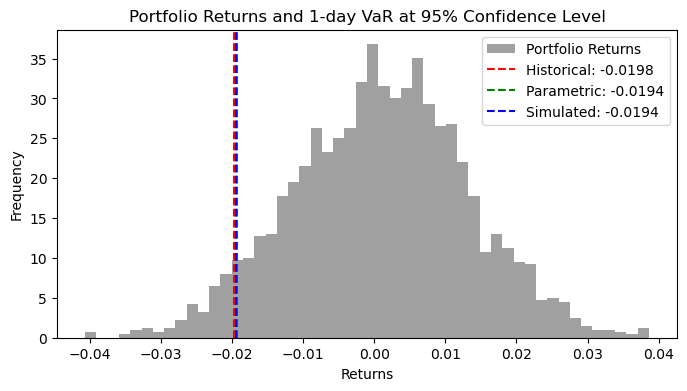

In [32]:
display(fig_var)